In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the file path
file_path = (
    "/home/christopher/sciebo/SoSe2026/HPC Lab/Analyse/Lab 2/tables/assignment4_all.csv"
)

df_all = pd.read_csv(file_path)

# map column names for less text
name = "run_name"
intAlu = "board.processor.cores.core.commitStats0.committedInstType::IntAlu"
simdFma = "board.processor.cores.core.commitStats0.committedInstType::SimdFloatMultAcc"
fma = "board.processor.cores.core.commitStats0.committedInstType::FloatMultAcc"
simdMisc = "board.processor.cores.core.commitStats0.committedInstType::SimdMisc"
totalInstructions = "board.processor.cores.core.commitStats0.committedInstType::total"
memRead = "board.processor.cores.core.commitStats0.committedInstType::MemRead"
memWrite = "board.processor.cores.core.commitStats0.committedInstType::MemWrite"
totalCycles = "board.processor.cores.core.numCycles"
ipc = "board.processor.cores.core.numCycles,board.processor.cores.core.ipc"
# extra columns calculated
ipcInt = "ipcInt"
ipcFloat = "ipcFloat"

# calculate extra columns
df_all[ipcInt] = df_all[intAlu] / df_all[totalCycles]
df_all[ipcFloat] = (df_all[simdFma] + df_all[fma]) / df_all[totalCycles]

# store config in df for better plotting
fetch1FetchLimit = "fetch1FetchLimit"
fetch2InputBufferSize = "fetch2InputBufferSize"
decodeInputWidth = "decodeInputWidth"
decodeInputBufferSize = "decodeInputBufferSize"
executeInputWidth = "executeInputWidth"
executeIssueLimit = "executeIssueLimit"
executeCommitLimit = "executeCommitLimit"
executeInputBufferSize = "executeInputBufferSize"

run_name_parts = df_all[name].str.split("_", expand=True)
expected_parts = 9
if run_name_parts.shape[1] < expected_parts:
    raise ValueError(
        f"Expected at least {expected_parts} underscore-separated parts in run_name"
    )
malformed_mask = run_name_parts.iloc[:, :expected_parts].isna().any(axis=1)
if malformed_mask.any():
    bad_run_names = df_all.loc[malformed_mask, name].tolist()
    raise ValueError(f"Malformed run_name values: {bad_run_names}")

df_all[fetch1FetchLimit] = pd.to_numeric(
    run_name_parts.iloc[:, 1], errors="raise"
).astype(int)
df_all[fetch2InputBufferSize] = pd.to_numeric(
    run_name_parts.iloc[:, 2], errors="raise"
).astype(int)
df_all[decodeInputWidth] = pd.to_numeric(
    run_name_parts.iloc[:, 3], errors="raise"
).astype(int)
df_all[decodeInputBufferSize] = pd.to_numeric(
    run_name_parts.iloc[:, 4], errors="raise"
).astype(int)
df_all[executeInputWidth] = pd.to_numeric(
    run_name_parts.iloc[:, 5], errors="raise"
).astype(int)
df_all[executeIssueLimit] = pd.to_numeric(
    run_name_parts.iloc[:, 6], errors="raise"
).astype(int)
df_all[executeCommitLimit] = pd.to_numeric(
    run_name_parts.iloc[:, 7], errors="raise"
).astype(int)
df_all[executeInputBufferSize] = (
    run_name_parts.iloc[:, 8]
    .astype(str)
    .str.contains("8", na=False)
    .map({True: 8, False: 16})
    .astype(int)
)

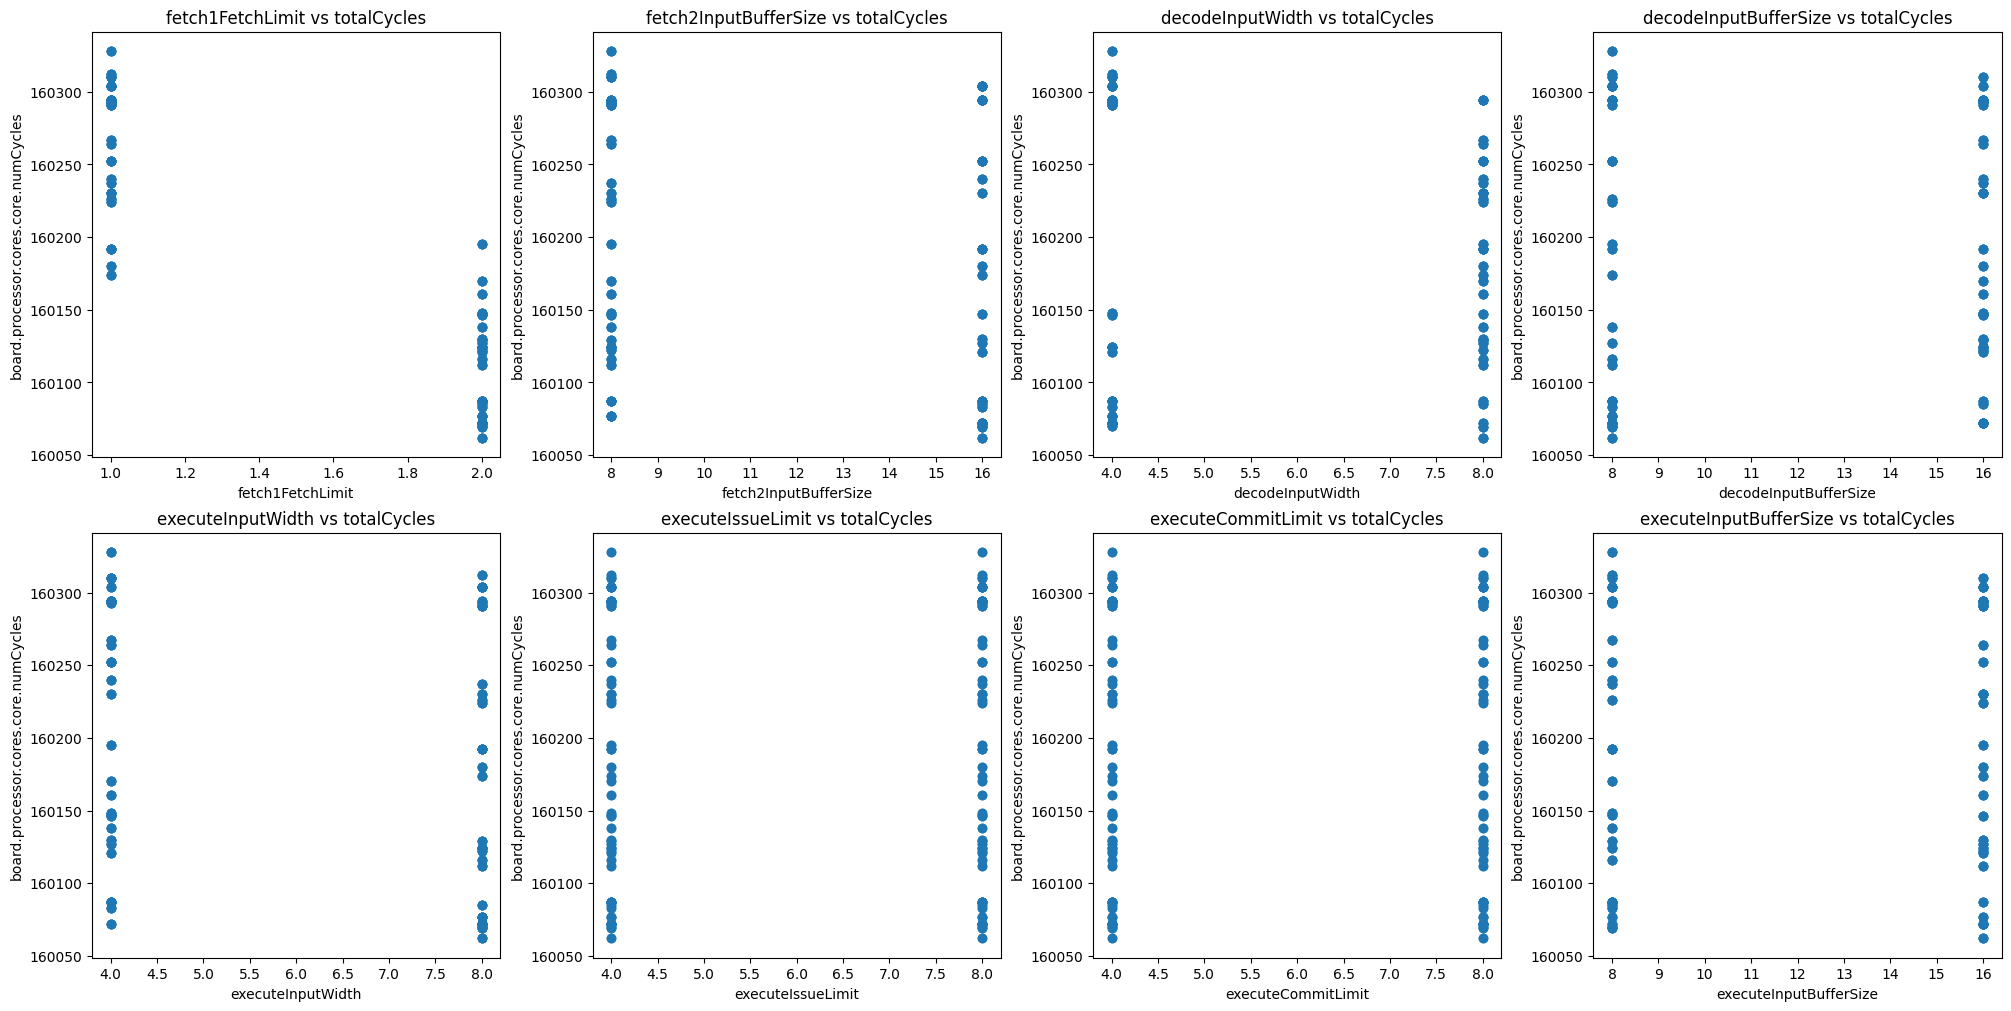

In [25]:
x_columns = [
    fetch1FetchLimit,
    fetch2InputBufferSize,
    decodeInputWidth,
    decodeInputBufferSize,
    executeInputWidth,
    executeIssueLimit,
    executeCommitLimit,
    executeInputBufferSize,
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)

for ax, x_column in zip(axes.flat, x_columns):
    ax.scatter(df_all[x_column], df_all[totalCycles], color="tab:blue")
    ax.set_xlabel(x_column)
    ax.set_ylabel(totalCycles)
    ax.set_title(f"{x_column} vs totalCycles")

plt.show()


Sort by cycles ascending to see which one is fastest

In [33]:
df_sorted = df_all.sort_values(ipcFloat, ascending=True)
print(df_sorted[ipcFloat].max())
print(df_sorted[ipcFloat].min())
print(df_sorted[ipcFloat].mean())
print(df_sorted[ipcFloat].median())
# calculate std deviation
print(df_sorted[ipcFloat].std())
df_sorted.head(10)

1.8742737189339131
1.8711641135671873
1.8728042399429539
1.872928073975888
0.0010422165434349547


,run_name,board.processor.cores.core.commitStats0.committedInstType::IntAlu,board.processor.cores.core.commitStats0.committedInstType::SimdFloatMultAcc,board.processor.cores.core.commitStats0.committedInstType::FloatMultAcc,board.processor.cores.core.commitStats0.committedInstType::SimdMisc,board.processor.cores.core.commitStats0.committedInstType::total,board.processor.cores.core.commitStats0.committedInstType::MemRead,board.processor.cores.core.commitStats0.committedInstType::MemWrite,board.processor.cores.core.numCycles,board.processor.cores.core.ipc,ipcInt,ipcFloat,fetch1FetchLimit,fetch2InputBufferSize,decodeInputWidth,decodeInputBufferSize,executeInputWidth,executeIssueLimit,executeCommitLimit,executeInputBufferSize
81,out_1_8_4_8_4_4_4_8,20011.0,300000.0,0.0,0.0,320016.0,5.0,0.0,160328.0,1.995977,0.124813,1.871164,1,8,4,8,4,4,4,8
83,out_1_8_4_8_4_4_8_8,20011.0,300000.0,0.0,0.0,320016.0,5.0,0.0,160328.0,1.995977,0.124813,1.871164,1,8,4,8,4,4,8,8
87,out_1_8_4_8_4_8_8_8,20011.0,300000.0,0.0,0.0,320016.0,5.0,0.0,160328.0,1.995977,0.124813,1.871164,1,8,4,8,4,8,8,8
85,out_1_8_4_8_4_8_4_8,20011.0,300000.0,0.0,0.0,320016.0,5.0,0.0,160328.0,1.995977,0.124813,1.871164,1,8,4,8,4,8,4,8
93,out_1_8_4_8_8_8_4_8,20011.0,300000.0,0.0,0.0,320016.0,5.0,0.0,160312.0,1.996176,0.124825,1.871351,1,8,4,8,8,8,4,8
95,out_1_8_4_8_8_8_8_8,20011.0,300000.0,0.0,0.0,320016.0,5.0,0.0,160312.0,1.996176,0.124825,1.871351,1,8,4,8,8,8,8,8
91,out_1_8_4_8_8_4_8_8,20011.0,300000.0,0.0,0.0,320016.0,5.0,0.0,160312.0,1.996176,0.124825,1.871351,1,8,4,8,8,4,8,8
89,out_1_8_4_8_8_4_4_8,20011.0,300000.0,0.0,0.0,320016.0,5.0,0.0,160312.0,1.996176,0.124825,1.871351,1,8,4,8,8,4,4,8
86,out_1_8_4_8_4_8_8_16,20011.0,300000.0,0.0,0.0,320016.0,5.0,0.0,160310.0,1.996201,0.124827,1.871374,1,8,4,8,4,8,8,16
84,out_1_8_4_8_4_8_4_16,20011.0,300000.0,0.0,0.0,320016.0,5.0,0.0,160310.0,1.996201,0.124827,1.871374,1,8,4,8,4,8,4,16


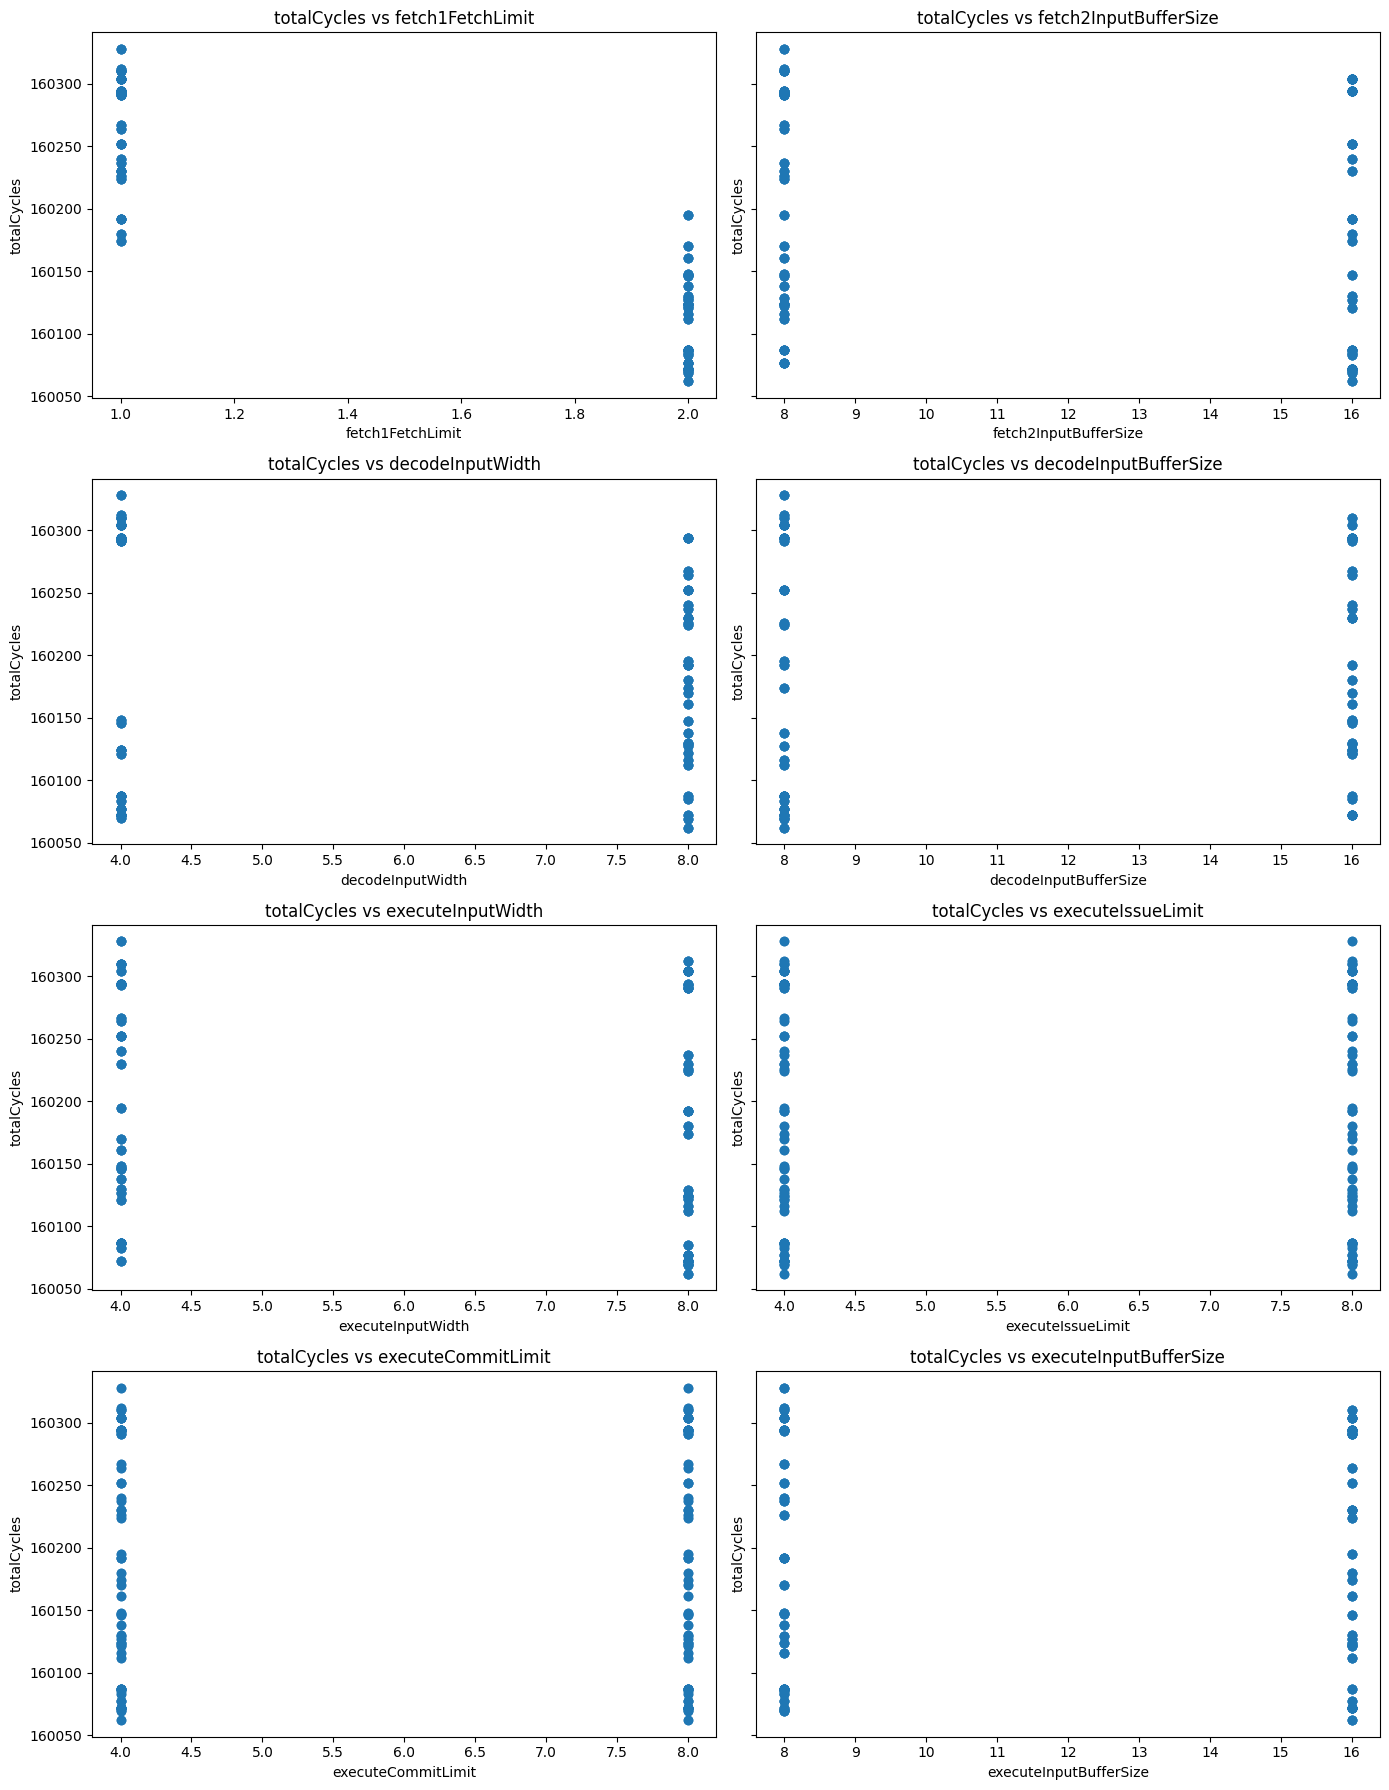

In [27]:
import matplotlib.pyplot as plt

x_columns = [
    "fetch1FetchLimit",
    "fetch2InputBufferSize",
    "decodeInputWidth",
    "decodeInputBufferSize",
    "executeInputWidth",
    "executeIssueLimit",
    "executeCommitLimit",
    "executeInputBufferSize",
]

fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharey=True)
axes = axes.flatten()

for ax, column in zip(axes, x_columns):
    ax.scatter(df_all[column], df_all[totalCycles], color="tab:blue")
    ax.set_xlabel(column)
    ax.set_ylabel("totalCycles")
    ax.set_title(f"totalCycles vs {column}")

plt.tight_layout()
plt.show()
